In [1]:
import os
import sys
import random
import numpy as np
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

import tensorflow as tf

from src.networks.DecoderPINN import PINN
from src.data.collocation import generate_boundary_grid, generate_interior_grid
from src.data.decoder_dataloader import load_fem_data
from src.physics.physics import get_M_non_const

from src.visualization.historyplots import plot_adam_history
from src.visualization.pdeplots import plot_pinn_solution
from src.hyperparameters import hypers_fixedscar as h
from src.optimization.DecoderTrainer import DecoderTrainer

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float32')
number_type = tf.float32

2026-10-03 15:15:16.537754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791033316.548185   73830 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791033316.551752   73830 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791033316.560507   73830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033316.560542   73830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033316.560544   73830 computation_placer.cc:177] computation placer alr

In [ ]:
output_dir = 'models/pipeline_evolution/02_fixed_scar'
result_dir = 'results/pipeline_evolution/02_fixed_scar'
data_path = 'data/fixed_scar/dataset.npz'
scale_save_path = 'data/fixed_scar/u_scale.npy'

# Load FEM data and scale
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_fem_data(
    data_path=data_path,
    scale_save_path=scale_save_path,
    number_type=number_type)

Loading FEM data from:
data/fixed_scar/dataset.npz
U_SCALE: 0.0633802938996219


I0000 00:00:1791032759.556558   70463 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Shape x_train: (2000, 2)
Shape x_val:   (500, 2)
Shape x_test:  (500, 2)


In [ ]:
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 2)))

initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=2500,      
    decay_rate=0.9,        
    staircase=False        
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
optimizer.build(model.trainable_variables)


def point_generator_fn():
    x_int = generate_interior_grid(N=h.N_INTERIOR_ADAM, split_scar=0.3)
    x_boundary, n_boundary = generate_boundary_grid(N_activation=h.N_ACTIVATION_ADAM, N_neumann=h.N_BOUNDARY_ADAM, r=1.0 / 400)
    num_neumann = 4 * h.N_BOUNDARY_ADAM

    x_int = tf.cast(x_int, dtype=number_type)
    x_boundary = tf.cast(x_boundary, dtype=number_type)
    n_boundary = tf.cast(n_boundary, dtype=number_type)

    return x_int, x_boundary, n_boundary, num_neumann

In [ ]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_ADAM,
    'neu': h.LAMBDA_NEU_ADAM,
    'dir': h.LAMBDA_DIR_ADAM,
    'data': h.LAMBDA_DATA_ADAM
}

trainer = DecoderTrainer(model=model, output_dir=output_dir, result_dir=result_dir)

trainer.train_adam(optimizer=optimizer,
                   epochs=h.EPOCHS_DECODER_ADAM,
                   x_train=x_train_pinn,
                   u_train=u_train_pinn,
                   x_val=x_val_pinn,
                   u_val=u_val_pinn,
                   physics_fn=get_M_non_const,
                   lambdas=lambdas,
                   point_generator_fn=point_generator_fn,
                   batch_size=h.BATCH_SIZE_DECODER_ADAM,
                   patience=h.PATIENCE_DECODER_ADAM,
                   number_type=number_type
                   )




Starting Adam optimization...


I0000 00:00:1791032761.620470   70463 service.cc:152] XLA service 0x577a8be78160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791032761.620520   70463 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791032762.080121   70463 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791032765.530567   70463 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.0424e+00 | PDE: 1.8828e-03 | Dir: 1.9293e-03 | Neu: 2.3633e-05 | Data: 8.4755e-02 | Val: 2.9060e-02
Epoch  500 | Loss: 3.2543e-02 | PDE: 2.7571e-03 | Dir: 2.1742e-05 | Neu: 1.9756e-04 | Data: 2.7610e-03 | Val: 4.3128e-03
Epoch 1000 | Loss: 1.9081e-02 | PDE: 3.5226e-03 | Dir: 9.0613e-06 | Neu: 1.9111e-04 | Data: 1.4650e-03 | Val: 4.0675e-03
Epoch 1500 | Loss: 3.7863e-02 | PDE: 2.2777e-03 | Dir: 5.7752e-06 | Neu: 1.2313e-04 | Data: 3.5006e-03 | Val: 3.8195e-03
Epoch 2000 | Loss: 2.8680e-02 | PDE: 1.7052e-03 | Dir: 4.0740e-06 | Neu: 8.7282e-05 | Data: 2.6567e-03 | Val: 3.7143e-03
Epoch 2500 | Loss: 2.2785e-02 | PDE: 3.1657e-03 | Dir: 2.2342e-06 | Neu: 7.5878e-05 | Data: 1.9395e-03 | Val: 3.2926e-03
Epoch 3000 | Loss: 3.6991e-02 | PDE: 3.0531e-03 | Dir: 2.5600e-06 | Neu: 7.0184e-05 | Data: 3.3681e-03 | Val: 3.1367e-03
Epoch 3500 | Loss: 7.5949e-03 | PDE: 2.1229e-03 | Dir: 5.4198e-07 | Neu: 1.7442e-05 | Data: 5.4176e-04 | Val: 2.4433e-03
Epoch 4000 | Loss: 8.6393e-03 | 

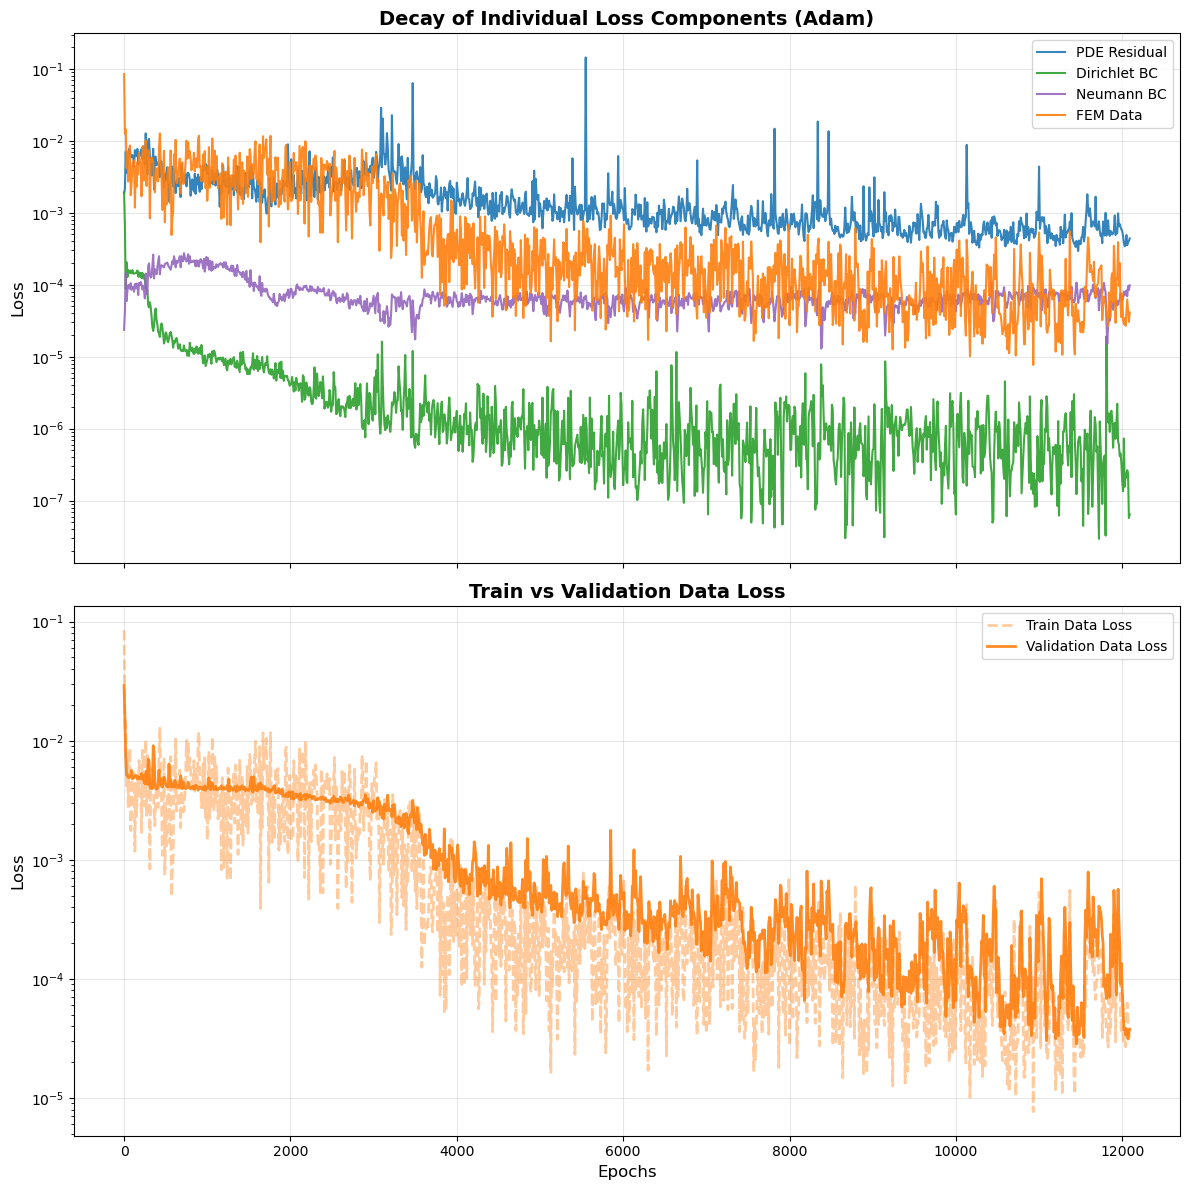

In [ ]:
history_adam_path = os.path.join(output_dir, 'decoder_adam.loss.npz')
np.savez(history_adam_path, **trainer.history_adam)
plot_adam_history(trainer.history_adam, save_freq=10)

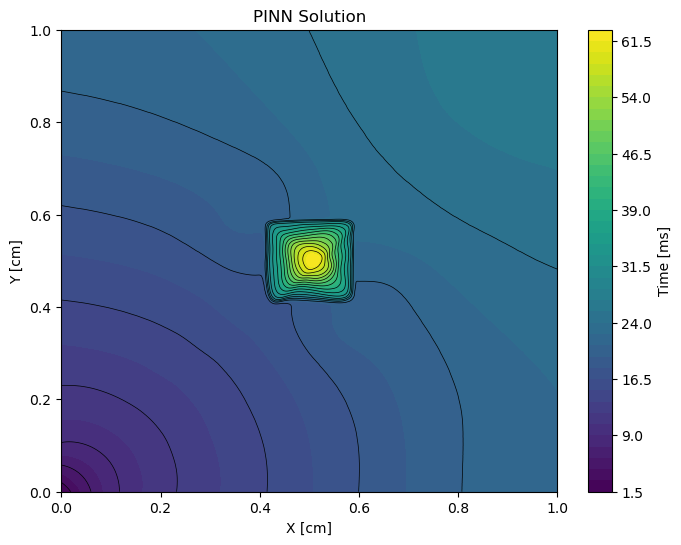

In [ ]:
N_plot = 400
plot_pinn_solution(N_plot,model=model, U_SCALE=U_SCALE)

In [ ]:
# TEST
u_pred = model(x_test_pinn)
test_mse = tf.reduce_mean(tf.square(u_pred - u_test_pinn)).numpy()
test_mae = tf.reduce_mean(tf.abs(u_pred - u_test_pinn)).numpy() * U_SCALE * 1000.0

print(f"Test MSE (Adimensionale): {test_mse:.6e}")
print(f"Test MAE (Fisico): {test_mae:.4f} ms")

Test MSE (Adimensionale): 5.316850e-05
Test MAE (Fisico): 0.2009 ms
